<a href="https://colab.research.google.com/github/isaacmutuma/federated-subset-scanning-pads/blob/main/Data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#Imports
from google.colab import drive
drive.mount('/content/drive')
import os
import os.path as osp
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
dataset_path = "/content/drive/MyDrive/pads-parkisons-dataset-folder"
os.listdir(dataset_path)

['pads-parkinsons-disease-smartwatch-dataset-1.0.0.zip', 'manifest.csv']

In [35]:


zip_path = "/content/drive/MyDrive/pads-parkisons-dataset-folder/pads-parkinsons-disease-smartwatch-dataset-1.0.0.zip"
extract_path = "/content/pads_dataset"

import zipfile
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

os.listdir(extract_path)

['pads-parkinsons-disease-smartwatch-dataset-1.0.0']

In [36]:
base_path = f"{extract_path}/pads-parkinsons-disease-smartwatch-dataset-1.0.0"
os.listdir(base_path)

['SHA256SUMS.txt',
 'questionnaire',
 'LICENSE.txt',
 'preprocessed',
 'patients',
 'scripts',
 'movement']

In [37]:
# file paths
base_path = f"{extract_path}/pads-parkinsons-disease-smartwatch-dataset-1.0.0"
timeseries_dir = f"{base_path}/movement/timeseries"
observation_dir = f"{base_path}/movement"
patients_dir = f"{base_path}/patients"

In [38]:
# load the timeseries file
def load_timeseries(filepath):
    columns = ["Time", "Accel_X", "Accel_Y", "Accel_Z", "Gyro_X", "Gyro_Y", "Gyro_Z"]
    df = pd.read_csv(filepath, header=None, names=None)
    return df

In [39]:
filepath = f"{timeseries_dir}/001_Relaxed_LeftWrist.txt"
df = load_timeseries(filepath)
print(df.head(5))
print(df.shape)

In [40]:

def get_patient_label(patient_id,patients_dir):
  individual_file= f"patient_{patient_id:03d}.json" # the padding ensures we can enter an int without thinking about the zeros
  file_path=osp.join(patients_dir,individual_file)

  # reading the file contents
  with open(file_path) as file:
    contents = json.load(file)
    #  get the condition for each patient
    condition= contents.get("condition")

    return condition


In [41]:
label= get_patient_label(1,patients_dir)
print(label)

Healthy


In [42]:
def build_manifest(patients_dir, observation_dir, n_patients=469):
    rows = []
    for pat_num in range(1, n_patients + 1):
        patient_id = f"{pat_num:03d}"
        label = get_patient_label(pat_num, patients_dir)

        obs_path = osp.join(observation_dir, f"observation_{patient_id}.json")
        with open(obs_path) as f:
            obs_contents = json.load(f)

        for session in obs_contents["session"]:
            activity_name = session.get("record_name")
            for record in session['records']:
                left_right_wrist = record.get('device_location' )
                filename = record.get('file_name')
                rows.append({
                    "patient_id": patient_id,
                    "label": label,
                    "task": activity_name,
                    "wrist": left_right_wrist,
                    "filepath": filename
                })

    return pd.DataFrame(rows)


full_path = osp.join(base_path, "movement", row["filepath"])
df = load_timeseries(full_path)

In [56]:
manifest = build_manifest(patients_dir, observation_dir, n_patients=469)
#print(manifest.to_string(index=False))
print(manifest.shape)          # expected (469 * 11 * 2, 5) = (10318, 5)
print(manifest.label.value_counts())   # expected roughly: 291 PD-ish, 99 DD-ish, 79 HC-ish subjects worth of rows
print(manifest.isnull().sum()) # any column with nulls = a real problem to chase down
manifest.to_csv("/content/drive/MyDrive/pads-parkisons-dataset-folder/manifest.csv", index=False)



(10318, 5)
label
Parkinson's                 6072
Healthy                     1738
Other Movement Disorders    1320
Essential Tremor             616
Atypical Parkinsonism        330
Multiple Sclerosis           242
Name: count, dtype: int64
patient_id    0
label         0
task          0
wrist         0
filepath      0
dtype: int64


In [59]:
healthy_df = manifest[(manifest["label"] == "Healthy") &
                       (manifest["task"] == "Relaxed") &
                       (manifest["wrist"] == "RightWrist")]

pd_df = manifest[(manifest["label"] == "Parkinson's") &
                  (manifest["task"] == "Relaxed") &
                  (manifest["wrist"] == "RightWrist")]

healthy_row =healthy_df.iloc[0]
pd_row=pd_df.iloc[0]
print(healthy_df.value_counts())
print(pd_df.value_counts())


patient_id  label    task     wrist       filepath                             
001         Healthy  Relaxed  RightWrist  timeseries/001_Relaxed_RightWrist.txt    1
003         Healthy  Relaxed  RightWrist  timeseries/003_Relaxed_RightWrist.txt    1
021         Healthy  Relaxed  RightWrist  timeseries/021_Relaxed_RightWrist.txt    1
027         Healthy  Relaxed  RightWrist  timeseries/027_Relaxed_RightWrist.txt    1
034         Healthy  Relaxed  RightWrist  timeseries/034_Relaxed_RightWrist.txt    1
                                                                                  ..
455         Healthy  Relaxed  RightWrist  timeseries/455_Relaxed_RightWrist.txt    1
457         Healthy  Relaxed  RightWrist  timeseries/457_Relaxed_RightWrist.txt    1
459         Healthy  Relaxed  RightWrist  timeseries/459_Relaxed_RightWrist.txt    1
463         Healthy  Relaxed  RightWrist  timeseries/463_Relaxed_RightWrist.txt    1
466         Healthy  Relaxed  RightWrist  timeseries/466_Relaxed_Right

In [91]:
def load_timeseries(absfilepath):
    columns = ["Time", "Accel_X", "Accel_Y", "Accel_Z", "Gyro_X", "Gyro_Y", "Gyro_Z"]
    df = pd.read_csv(absfilepath, header=None, names=columns)
    return df

healthy_signal={}
for healthy_pat in range(len(healthy_df)):
  patient_id = healthy_df.patient_id.iloc[healthy_pat]
  filepath= healthy_df["filepath"].iloc[healthy_pat]
  absfilepath=osp.join(base_path, "movement" ,filepath)
  healthy_signal[patient_id]=load_timeseries(absfilepath)


#print(healthy_signal)


# loop to load all the pd patients real data on right hand relaxed text
pd_signal={}
for pd_pat in range(len(pd_df)):
  patient_id = pd_df.patient_id.iloc[pd_pat]
  filepath= pd_df["filepath"].iloc[pd_pat]
  absfilepath=osp.join(base_path, "movement" ,filepath)
  pd_signal[patient_id]=load_timeseries(absfilepath)
print(pd_signal)




{'004':            Time   Accel_X   Accel_Y   Accel_Z    Gyro_X    Gyro_Y    Gyro_Z
0      0.000000  0.002494  0.003593 -0.001910 -0.002130  0.008050  0.003846
1      0.009666  0.004356  0.000665 -0.000867  0.001049  0.010193  0.002784
2      0.019808  0.004270  0.000670 -0.000810  0.002127  0.009134  0.001722
3      0.029805  0.002216  0.000666  0.002156  0.001292  0.007992  0.002862
4      0.039869  0.005099 -0.000318  0.001223 -0.004022  0.005816  0.001801
...         ...       ...       ...       ...       ...       ...       ...
2043  20.565872 -0.000670  0.001686  0.001370 -0.018784 -0.008150 -0.002435
2044  20.575743  0.000391  0.004495  0.000283 -0.012373 -0.009169 -0.004561
2045  20.585691  0.002445  0.007402  0.001183 -0.000602 -0.012242 -0.003504
2046  20.595787  0.001591  0.008424  0.000163  0.010092 -0.014271 -0.003507
2047  20.606153  0.002672  0.007572  0.000164  0.017530 -0.011023 -0.003507

[2048 rows x 7 columns], '005':            Time   Accel_X   Accel_Y   Accel_Z  

In [46]:
absfilepath=osp.join(base_path, "movement", pd_row["filepath"])
pd_signal =load_timeseries(absfilepath)
print(pd_signal)

           Time   Accel_X   Accel_Y   Accel_Z    Gyro_X    Gyro_Y    Gyro_Z
0      0.000000  0.002494  0.003593 -0.001910 -0.002130  0.008050  0.003846
1      0.009666  0.004356  0.000665 -0.000867  0.001049  0.010193  0.002784
2      0.019808  0.004270  0.000670 -0.000810  0.002127  0.009134  0.001722
3      0.029805  0.002216  0.000666  0.002156  0.001292  0.007992  0.002862
4      0.039869  0.005099 -0.000318  0.001223 -0.004022  0.005816  0.001801
...         ...       ...       ...       ...       ...       ...       ...
2043  20.565872 -0.000670  0.001686  0.001370 -0.018784 -0.008150 -0.002435
2044  20.575743  0.000391  0.004495  0.000283 -0.012373 -0.009169 -0.004561
2045  20.585691  0.002445  0.007402  0.001183 -0.000602 -0.012242 -0.003504
2046  20.595787  0.001591  0.008424  0.000163  0.010092 -0.014271 -0.003507
2047  20.606153  0.002672  0.007572  0.000164  0.017530 -0.011023 -0.003507

[2048 rows x 7 columns]


/tmp/ipykernel_3211/4074664652.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


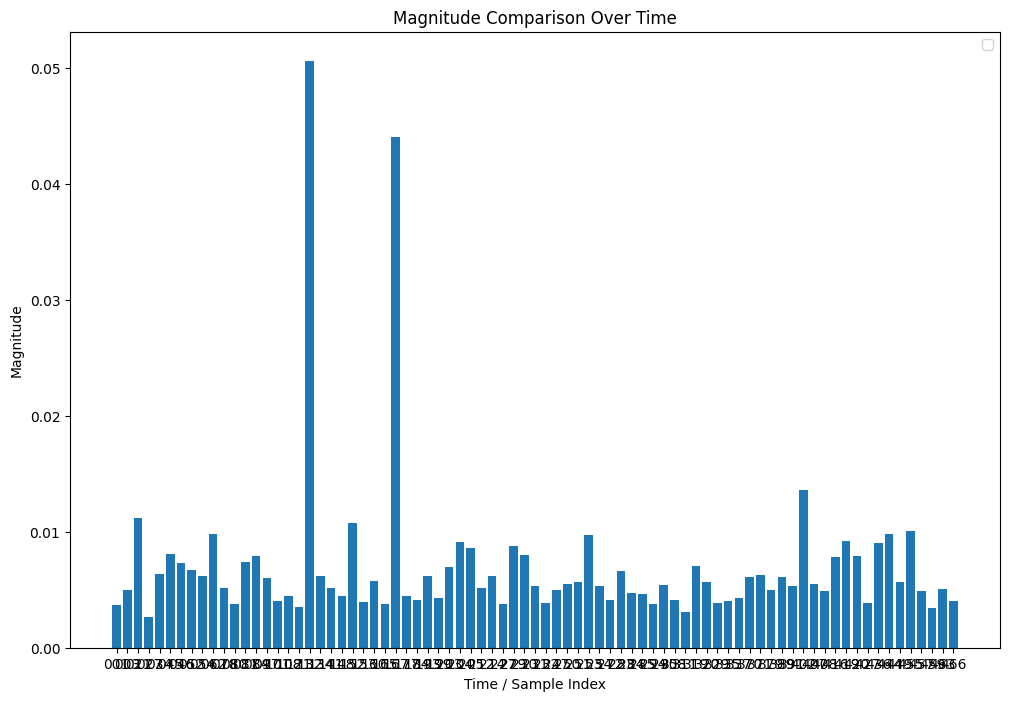

In [103]:
# with healthy and pd signal we need to now magnitude that just move motion regradless of the direction x,y or z

magnitude_healthy={}
for patient_id,signal in healthy_signal.items():
  mag=np.sqrt(signal["Accel_X" ]**2
        +signal["Accel_Y"]**2
        +signal["Accel_Z"]**2)
  magnitude_healthy[patient_id]=mag
averaged_values = [np.mean(v) for v in magnitude_healthy.values()]

magnitude_pd={}
for patient_id,signal in pd_signal.items():
  mag=np.sqrt(signal["Accel_X" ]**2
        +signal["Accel_Y"]**2
        +signal["Accel_Z"]**2)
  magnitude_pd[patient_id]=mag


# plot of both signals
plt.figure(figsize=(12, 8))
plt.bar( magnitude_healthy.keys(),averaged_values )

plt.xlabel('Time / Sample Index')
plt.ylabel('Magnitude')
plt.title('Magnitude Comparison Over Time')
plt.legend()
plt.show()





